In [9]:
# Data handling
import pandas as pd
import numpy as np

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [11]:
# Load dataset
df = pd.read_csv("Housing.csv")

# Select relevant columns
df = df[['bedrooms', 'bathrooms', 'area', 'price']].dropna()

# Reduce dataset size (for faster training)
df = df.head(150)

print("df.head: ", df.head())


df.head:     bedrooms  bathrooms  area     price
0         4          2  7420  13300000
1         4          4  8960  12250000
2         3          2  9960  12250000
3         4          2  7500  12215000
4         4          1  7420  11410000


In [12]:
# Features (input) and target (output)
X_tab = df[['bedrooms', 'bathrooms', 'area']]
y = df['price']

# Scale tabular features (important for neural networks)
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)

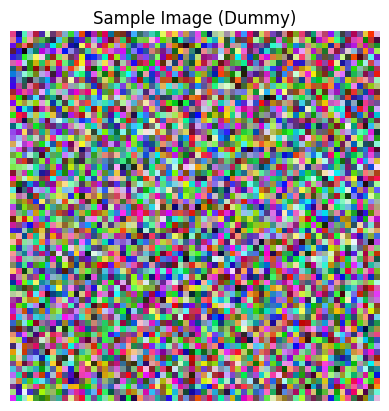

In [25]:
# Image size
IMG_SIZE = 64

# Creating random images (for demonstration only)
# In real case, yahan actual house images load hoti hain
X_img = np.random.rand(len(df), IMG_SIZE, IMG_SIZE, 3)

import matplotlib.pyplot as plt

plt.imshow(X_img[0])
plt.title("Sample Image (Dummy)")
plt.axis('off')
plt.show()

In [14]:
# Split both tabular and image data
X_tab_train, X_tab_test, X_img_train, X_img_test, y_train, y_test = train_test_split(
    X_tab, X_img, y, test_size=0.2, random_state=42
)

In [15]:
# Input layer for images
image_input = layers.Input(shape=(64, 64, 3))

# Convolution + Pooling layers
x = layers.Conv2D(16, (3,3), activation='relu')(image_input)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

# Flatten to convert into 1D vector
x = layers.Flatten()(x)

# Dense layer to extract image features
image_features = layers.Dense(32, activation='relu')(x)

In [16]:
# Input layer for tabular data (3 features)
tabular_input = layers.Input(shape=(3,))

# Fully connected layers
t = layers.Dense(32, activation='relu')(tabular_input)
t = layers.Dense(16, activation='relu')(t)

In [17]:
# Combine image features + tabular features
combined = layers.concatenate([image_features, t])

In [18]:
# Final prediction layer (price)
z = layers.Dense(1)(combined)

In [19]:
# Create multimodal model
model = models.Model(
    inputs=[image_input, tabular_input],
    outputs=z
)

In [20]:
model.compile(
    optimizer='adam',
    loss='mse',   # Regression problem
    metrics=['mae']
)

In [21]:
model.fit(
    [X_img_train, X_tab_train],
    y_train,
    validation_data=([X_img_test, X_tab_test], y_test),
    epochs=5,
    batch_size=16
)

Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 54901694529536.0000 - mae: 7237170.0000 - val_loss: 51723670388736.0000 - val_mae: 7087703.0000
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 54900868251648.0000 - mae: 7237111.5000 - val_loss: 51722022027264.0000 - val_mae: 7087586.5000
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 54898108399616.0000 - mae: 7236923.5000 - val_loss: 51717374738432.0000 - val_mae: 7087258.5000
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 54891158437888.0000 - mae: 7236439.5000 - val_loss: 51706440187904.0000 - val_mae: 7086486.5000
Epoch 5/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 54875702427648.0000 - mae: 7235368.5000 - val_loss: 51683849666560.0000 - val_mae: 7084893.5000


In [23]:
# Predictions
preds = model.predict([X_img_test, X_tab_test])

# Flatten predictions (important fix)
preds = preds.flatten()

# Metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("MAE:", mae)
print("RMSE:", rmse)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
MAE: 7084893.0
RMSE: 7189148.34044089


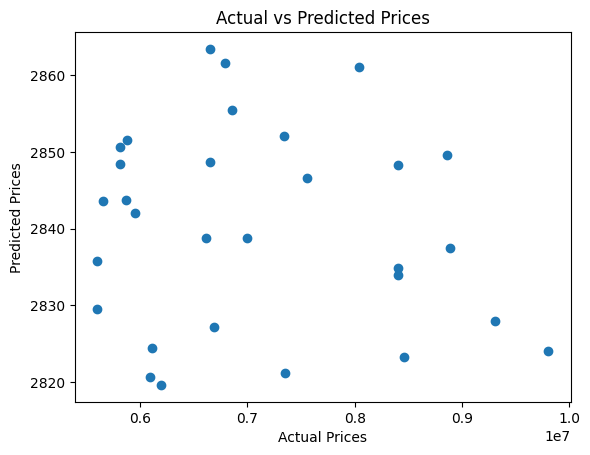

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()